In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from matplotlib.colors import ListedColormap, BoundaryNorm


# # import the data file : results.viznodes
# data_rad_file = "/Users/dger0683/ChasteWorkspace/chaste_output/Test02aMonlayerGrowth/results_from_time_0/cellareas.dat"
# if not os.path.isfile(data_rad_file):
#     print(f"Data file {data_rad_file} not found.")
#     sys.exit(1)

# data_surf_file = "/Users/dger0683/ChasteWorkspace/chaste_output/Test02aMonlayerGrowth/results_from_time_0/celldata_FreeSurfaceFraction.dat"
# if not os.path.isfile(data_surf_file):
#     print(f"Data file {data_surf_file} not found.")
#     sys.exit(1)

# data_area_file = "/Users/dger0683/ChasteWorkspace/chaste_output/Test02aMonlayerGrowth/results_from_time_0/celldata_FreeAreaFraction.dat"
# if not os.path.isfile(data_area_file):
#     print(f"Data file {data_area_file} not found.")
#     sys.exit(1)

In [2]:
def import_data_files(key,beta_ind,gamma_ind, end_time, index):

    # import the data file : results.viznodes
    data_rad_file = f"/Users/dger0683/ChasteWorkspace/chaste_output/{key}MonolayerGrowth_Beta{beta_ind}_Gamma{gamma_ind}_EndTime{end_time}/results_from_time_0/celldata_Radius.dat"
    if not os.path.isfile(data_rad_file):
        print(f"Data file {data_rad_file} not found.")
        sys.exit(1)

    data_surf_file = f"/Users/dger0683/ChasteWorkspace/chaste_output/{key}MonolayerGrowth_Beta{beta_ind}_Gamma{gamma_ind}_EndTime{end_time}/results_from_time_0/celldata_FreeSurfaceFraction.dat"
    if not os.path.isfile(data_surf_file):
        print(f"Data file {data_surf_file} not found.")
        sys.exit(1)

    data_area_file = f"/Users/dger0683/ChasteWorkspace/chaste_output/{key}MonolayerGrowth_Beta{beta_ind}_Gamma{gamma_ind}_EndTime{end_time}/results_from_time_0/celldata_FreeAreaFraction.dat"
    if not os.path.isfile(data_area_file):
        print(f"Data file {data_area_file} not found.")
        sys.exit(1)

    inhibited_growth_file = f"/Users/dger0683/ChasteWorkspace/chaste_output/{key}MonolayerGrowth_Beta{beta_ind}_Gamma{gamma_ind}_EndTime{end_time}/results_from_time_0/celldata_growth inhibited.dat"
    if not os.path.isfile(inhibited_growth_file):
        print(f"Data file {inhibited_growth_file} not found.")
        sys.exit(1)
    # extract the relavent data from the files
    # open the loggedcell.dat file, and go straight to the last row
    data_list = []
    with open(data_rad_file, 'r') as f:
        for line in f:
            line = line.strip()
            if line:  # skip empty lines
                row = list(map(float, line.split()))
                data_list.append(row)

    final_row = data_list[index][1:]
    # print(f"Final row (excluding time): {final_row}")
    x_vals = final_row[2::5]
    y_vals = final_row[3::5]
    r_vals = final_row[4::5]
    for i in range(len(r_vals)):
        r_vals[i] = np.sqrt(r_vals[i]/np.pi)

    data_surf = []
    with open(data_surf_file, 'r') as f:
        for line in f:
            line = line.strip()
            if line:  # skip empty lines
                row = list(map(float, line.split()))
                data_surf.append(row)
    surface_fractions = data_surf[index][5::5]


    data_area = []
    with open(data_area_file, 'r') as f:
        for line in f:
            line = line.strip()
            if line:  # skip empty lines
                row = list(map(float, line.split()))
                data_area.append(row)
    area_fractions = data_area[index][5::5]

    data_inhibited = []
    with open(inhibited_growth_file, 'r') as f:
        for line in f:
            line = line.strip()
            if line:  # skip empty lines
                row = list(map(float, line.split()))
                data_inhibited.append(row)
    inhibited_cells = data_inhibited[index][5::5]

    return x_vals, y_vals, r_vals, surface_fractions, area_fractions, inhibited_cells


Processing β=0, γ=0
  Number of cells: 1001
Processing β=1, γ=0
  Number of cells: 1000
Processing β=2, γ=0
  Number of cells: 1001
Processing β=3, γ=0
  Number of cells: 1000
Processing β=4, γ=0
  Number of cells: 1000
Processing β=0, γ=1
  Number of cells: 1000
Processing β=1, γ=1
  Number of cells: 1000
Processing β=2, γ=1
  Number of cells: 1000
Processing β=3, γ=1
  Number of cells: 1000
Processing β=4, γ=1
  Number of cells: 1000
Processing β=0, γ=2
  Number of cells: 1000
Processing β=1, γ=2
  Number of cells: 1000
Processing β=2, γ=2
  Number of cells: 1000
Processing β=3, γ=2
  Number of cells: 1000
Processing β=4, γ=2
  Number of cells: 1000
Processing β=0, γ=3
  Number of cells: 1000
Processing β=1, γ=3
  Number of cells: 1000
Processing β=2, γ=3
  Number of cells: 1000
Processing β=3, γ=3
  Number of cells: 1000
Processing β=4, γ=3
  Number of cells: 1000
Processing β=0, γ=4
  Number of cells: 1000
Processing β=1, γ=4
  Number of cells: 1000
Processing β=2, γ=4
  Number of 

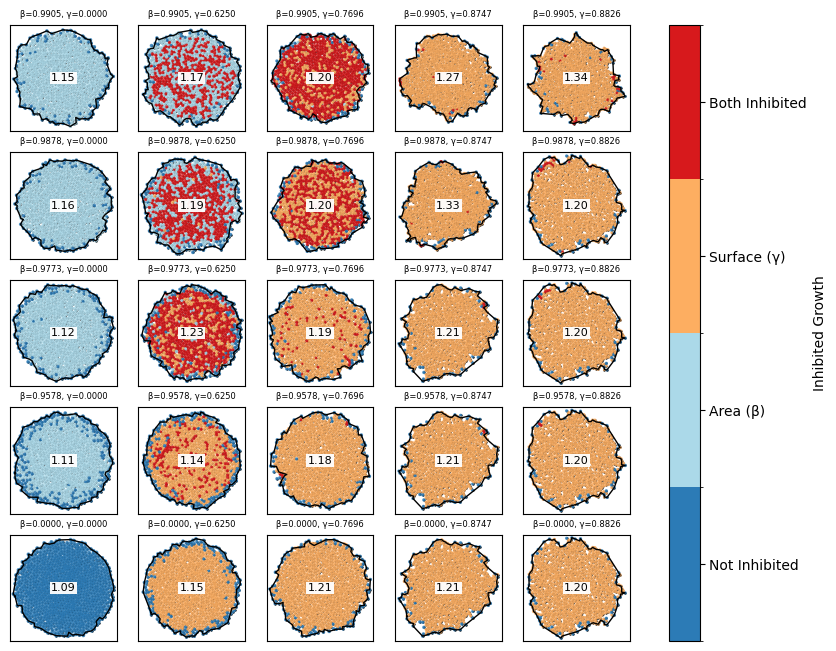

In [13]:
from shapely.geometry import Polygon
from concave_hull import concave_hull, concave_hull_indexes

# beta_vect = [0.0, 0.1, 0.25, 0.5, 0.75]
# gamma_vect = [0.0, 0.5, 0.75, 0.9, 0.95, 0.98]
# key = "LongTests_6/"
# end_time = 1000

beta_vect =  [0.0, 0.9577647499999999, 0.97731295, 0.9877978000000002, 0.9904919700000016]
gamma_vect = [0.0, 0.62498425, 0.7696174999999995, 0.8746966050000005, 0.8825565200000033]


key = "LongTests_Calibrted_V3/"
end_time = 2000

fig, axs = plt.subplots(len(beta_vect), len(gamma_vect), figsize=(10,8))
for gamma_ind, gamma_parameter in enumerate(gamma_vect):
    for beta_ind, beta_parameter in enumerate(beta_vect):
        print(f"Processing β={beta_ind}, γ={gamma_ind}")
        # if (beta_ind > 0 or gamma_ind > 0):
        # define discrete colors once (used after loop too)
        # discrete_colors = ['lightgray', 'green', 'orange', 'red']
        discrete_colors = [(44/255, 123/255, 182/255), 
                    (171/255, 217/255, 233/255), 
                    (253/255, 174/255, 97/255), 
                    (215/255, 25/255, 28/255)]
        ax = axs[4 - beta_ind, gamma_ind]  # get axis up front (so except can still use it)

        try:
            x_vals, y_vals, r_vals, surface_fractions, area_fractions, inhibited_cells = import_data_files(
                key, beta_ind, gamma_ind, end_time, -1)
            print(f"  Number of cells: {len(x_vals)}")

            # create 2D numpy array of points
            points = np.column_stack((x_vals, y_vals))
            hull_indexes = concave_hull_indexes(points, concavity = 1.5, length_threshold = 0.0)
            hull_points = concave_hull(points[hull_indexes])

            # find the area of the concave hull
            hull_polygon = Polygon(hull_points)
            hull_area = hull_polygon.area
            # print(f"Concave hull area: {hull_area}")
            # calculate the length of the concave hull perimeter
            hull_perimeter = hull_polygon.length
            # print(f"Concave hull perimeter: {hull_perimeter}")

            # calculate the circularity
            # circularity = 4 * np.pi * hull_area / (hull_perimeter ** 2)
            # print(f"Circularity: {circularity}")

            roughness = hull_perimeter / (2*np.pi * np.sqrt(hull_area/np.pi))
            # print(f"Roughness: {roughness}")


            ax.scatter(x_vals, y_vals, s=0.5, color='black')

            inhibited_cell_priv = []
            for af, sf in zip(area_fractions, surface_fractions):
                ih_i = 0
                if af < beta_parameter:
                    ih_i += 1
                if sf < gamma_parameter:
                    ih_i += 2
                inhibited_cell_priv.append(ih_i)

            for (x, y, r, ih) in zip(x_vals, y_vals, r_vals, inhibited_cell_priv):
                color = discrete_colors[ih]
                circle = plt.Circle((x, y), r, color=color, fill=True, alpha=0.75)
                ax.add_artist(circle)

            ax.set_title(f'β={beta_parameter:.4f}, γ={gamma_parameter:.4f}', fontsize=6)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.axis('equal')
            # add text in the center of the plot with roughness value
            ax.text(0.5, 0.5, f'{roughness:.2f}', transform=ax.transAxes,
                    fontsize=8, color='black', ha='center', va='center',
                    bbox=dict(facecolor='white', alpha=0.95, edgecolor='none', pad=1.0))
            
            hull_x = [p[0] for p in hull_points]
            hull_y = [p[1] for p in hull_points]
            ax.plot(hull_x + [hull_x[0]], hull_y + [hull_y[0]], color='black', linewidth=1.0)

            




        except SystemExit:
            # import_data_files used sys.exit -> handle separately
            print(f"Skipping β={beta_ind}, γ={gamma_ind} due to missing files (SystemExit).")
            ax.set_title(f'β={beta_parameter:.4f}, γ={gamma_parameter:.4f}\nData Not Available', fontsize=6)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.axis('equal')

        except Exception as e:
            print(f"Skipping β={beta_ind}, γ={gamma_ind} due to error: {e}")
            ax.set_title(f'β={beta_parameter:.4f}, γ={gamma_parameter:.4f}\nError', fontsize=6)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.axis('equal')

# fig.suptitle('Inhibited Growth Cells Highlighted')

# sm = plt.cm.ScalarMappable(norm=plt.Normalize(0, 3), cmap='inferno_r')
# sm.set_array([])

cmap_ih = ListedColormap(discrete_colors)
norm_ih_disc = BoundaryNorm([0, 1, 2, 3, 4], cmap_ih.N)
sm = plt.cm.ScalarMappable(norm=norm_ih_disc, cmap=cmap_ih)
sm.set_array([])
# make room on the right for the colorbar
# plt.tight_layout(rect=[0, 0, 0.9, 1])
# place an axes for the colorbarxw
# cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])

cbar = fig.colorbar(
    sm,
    ax=axs,
    boundaries=[0, 1, 2, 3],
    ticks=[0, 1, 2, 3],
    label='Inhibited Growth',
)
# center labels on each discrete color band
cbar.set_ticks([0.5, 1.5, 2.5, 3.5])
cbar.set_ticklabels(['Not Inhibited', 'Area (β)', 'Surface (γ)', 'Both Inhibited'])


plt.show()
fig.savefig("inhibited_growth_cells.png", dpi=500)



<!-- These are plots to generate figures for monolayer simulations. -->

In [3]:
def import_data_files_for_histograms(index, key):
    file_index = -1

    head = "/Users/dger0683/ChasteWorkspace/chaste_output/New/NoInhibition_strong_100/"

    # import the data file : results.viznodes. 
    # data_rad_file = f"{head}/{key}/MonolayerGrowth_Beta_Index{index}/results_from_time_0/cellareas.dat"
    data_rad_file = f"{head}/{key}/MonolayerGrowth_Beta_Index{index}/results_from_time_0/celldata_Radius.dat"
    if not os.path.isfile(data_rad_file):
        print(f"Data file {data_rad_file} not found.")
        sys.exit(1)

    data_surf_file = f"{head}/{key}/MonolayerGrowth_Beta_Index{index}/results_from_time_0/celldata_FreeSurfaceFraction.dat"
    if not os.path.isfile(data_surf_file):
        print(f"Data file {data_surf_file} not found.")
        sys.exit(1)

    data_area_file = f"{head}/{key}/MonolayerGrowth_Beta_Index{index}/results_from_time_0/celldata_FreeAreaFraction.dat"
    if not os.path.isfile(data_area_file):
        print(f"Data file {data_area_file} not found.")
        sys.exit(1)

    inhibited_growth_file = f"{head}/{key}/MonolayerGrowth_Beta_Index{index}/results_from_time_0/celldata_growth inhibited.dat"
    if not os.path.isfile(inhibited_growth_file):
        print(f"Data file {inhibited_growth_file} not found.")
        sys.exit(1)
    # extract the relavent data from the files
    # open the loggedcell.dat file, and go straight to the last row
    data_list = []
    with open(data_rad_file, 'r') as f:
        for line in f:
            line = line.strip()
            if line:  # skip empty lines
                row = list(map(float, line.split()))
                data_list.append(row)

    final_row = data_list[file_index][1:]
    # print(f"Final row (excluding time): {final_row}")
    x_vals = final_row[2::5]
    y_vals = final_row[3::5]
    r_vals = final_row[4::5]
    # for i in range(len(r_vals)):
    #     r_vals[i] = np.sqrt(r_vals[i]/np.pi)

    data_surf = []
    with open(data_surf_file, 'r') as f:
        for line in f:
            line = line.strip()
            if line:  # skip empty lines
                row = list(map(float, line.split()))
                data_surf.append(row)
    surface_fractions = data_surf[file_index][5::5]


    data_area = []
    with open(data_area_file, 'r') as f:
        for line in f:
            line = line.strip()
            if line:  # skip empty lines
                row = list(map(float, line.split()))
                data_area.append(row)
    area_fractions = data_area[file_index][5::5]

    data_inhibited = []
    with open(inhibited_growth_file, 'r') as f:
        for line in f:
            line = line.strip()
            if line:  # skip empty lines
                row = list(map(float, line.split()))
                data_inhibited.append(row)
    inhibited_cells = data_inhibited[file_index][5::5]

    return x_vals, y_vals, r_vals, surface_fractions, area_fractions, inhibited_cells


In [9]:
import csv
# iterate through all indices and collate the data
all_x_vals = []
all_y_vals = []
all_r_vals = []
all_surface_fractions = []
all_area_fractions = []
all_inhibited_cells = []
for index in range(100):
    # x_vals, y_vals, r_vals, surface_fractions, area_fractions, inhibited_cells = import_data_files_for_histograms(index, "100")
    x_vals, y_vals, r_vals, surface_fractions, area_fractions, inhibited_cells = import_data_files_for_histograms(index, "quadratic")
    all_x_vals.extend(x_vals)
    all_y_vals.extend(y_vals)
    all_r_vals.extend(r_vals)
    all_surface_fractions.extend(surface_fractions)
    all_area_fractions.extend(area_fractions)
    all_inhibited_cells.extend(inhibited_cells)

    output_file = f'CHASTE_MonolayerGrowth_1000_Data_QUADRATIC_SMALL_test9/cell_data_no_inhibition_{index}.csv'
    # check if output folder exists, if not create it
    output_folder = os.path.dirname(output_file)
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    with open(output_file, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['x_pos', 'y_pos', 'radius_i', 'f_i', 'a_i'])
        for x, y, r, sf, af in zip(x_vals, y_vals, r_vals, surface_fractions, area_fractions):
            writer.writerow([x, y, r, sf, af])
    print(f"Data exported to {output_file}")

print(f"Total number of cells across all simulations: {len(all_x_vals)}")
    

Data exported to CHASTE_MonolayerGrowth_1000_Data_QUADRATIC_SMALL_test9/cell_data_no_inhibition_0.csv
Data exported to CHASTE_MonolayerGrowth_1000_Data_QUADRATIC_SMALL_test9/cell_data_no_inhibition_1.csv
Data exported to CHASTE_MonolayerGrowth_1000_Data_QUADRATIC_SMALL_test9/cell_data_no_inhibition_2.csv
Data exported to CHASTE_MonolayerGrowth_1000_Data_QUADRATIC_SMALL_test9/cell_data_no_inhibition_3.csv
Data exported to CHASTE_MonolayerGrowth_1000_Data_QUADRATIC_SMALL_test9/cell_data_no_inhibition_4.csv
Data exported to CHASTE_MonolayerGrowth_1000_Data_QUADRATIC_SMALL_test9/cell_data_no_inhibition_5.csv
Data exported to CHASTE_MonolayerGrowth_1000_Data_QUADRATIC_SMALL_test9/cell_data_no_inhibition_6.csv
Data exported to CHASTE_MonolayerGrowth_1000_Data_QUADRATIC_SMALL_test9/cell_data_no_inhibition_7.csv
Data exported to CHASTE_MonolayerGrowth_1000_Data_QUADRATIC_SMALL_test9/cell_data_no_inhibition_8.csv
Data exported to CHASTE_MonolayerGrowth_1000_Data_QUADRATIC_SMALL_test9/cell_data_